<h1> Particle Swarm Optimization (PSO) </h1>

The PSO Idea

PSO is inspired by the flocking behavior of birds.

Imagine:

Several birds are searching for food.

Each bird:

Has a position.</br>
Has a velocity.

The main difference from GA:

In GA, a solution (chromosome) is modified.

In PSO, solutions move.

That is:

Position(t)

↓

Position(t+1)

...using velocity.

Key Components of PSO

Each particle has:

1) Position</br>
Current position

2) Velocity</br>
Movement speed

3) Personal Best</br>
The best position the particle itself has encountered

4) Global Best</br>
The best solution found by the entire swarm

Movement Mechanism

The two main equations of PSO:

1. Velocity Update

$v_i(t+1)= wv_i(t) + c_1r_1(pbest_i-x_i) + c_2r_2(gbest-x_i)$

1.1. Inertia:
$wv_i$</br>
Continuing along the previous path.</br>
$0.4≤w≤0.9$

1.2. Cognitive Component:
$c_1r_1(pbest-x_i)$</br>
Personal experience. "I found a better spot previously."</br>
$c1​=2$

1.3. Social Component:
$c_2r_2(gbest-x_i)$</br>
Learning from the group. "The best member of the group is here."</br>
$c2​=2$

$r1​,r2​$ : Random Factors

</br>

2. Position Update

$x_i(t+1)=x_i(t)+v_i(t+1)$

Meaning:

The particle moves.


Initialize Particles

        ↓

Evaluate Fitness

        ↓

Update pbest

        ↓

Update gbest

        ↓

Update Velocity

        ↓

Update Position

        ↓

Repeat

### Comparison with DE


|                | DE                    | PSO            |
| -------------- | --------------------- | -------------- |
| Representation | Vector                | Vector         |
| Population     | Individuals           | Particles      |
| Movement       | Differential mutation | Velocity       |
| Memory         | Doesn't have          | pbest/gbest    |
| Learning       | From others           | From itself and the group |


An interesting point is that PSO can be effectively compared with DE, as both share the following characteristics:

Representation: Vector

Continuous Optimization

However, their underlying philosophies differ:

DE:</br>
Uses the difference between individuals to generate movement.

PSO:</br>
Uses personal and social experience to drive movement.

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from src.PSO import (
    Particle,
    Swarm,
    particle_swarm_optimization,
)
from problems.benchmarks import (
    sphere_function,
    rosenbrock_function,
    rastrigin_function,
    ackley_function,
)

<h3> Step 1: Particle Class Initiation </h3>

In [4]:
bounds = [
    (-5,5),
    (-5,5)
]

particle = Particle(
    dimension=2,
    bounds=bounds
)

print("Position:", particle.position)
print("Velocity:", particle.velocity)
print("Best:", particle.best_position)
print("Best Fitness:", particle.best_fitness)

Position: [ 0.35813746 -2.13159282]
Velocity: [0. 0.]
Best: [ 0.35813746 -2.13159282]
Best Fitness: inf


<h3> Step 2: Swarm Initialization + Fitness Evaluation </h3>

In each iteration, we must:

Calculate the fitness of each particle.</br>
Update if it is better than pbest.</br>
Update if it is better than gbest.

In [5]:
bounds = [
    (-5,5),
    (-5,5)
]

swarm = Swarm(
    population_size=10,
    dimension=2,
    bounds=bounds,
    fitness_function=sphere_function
)

In [6]:
print("Global Best Position: ", swarm.global_best_position)
print("Global Best Fitness: ", swarm.global_best_fitness)

Global Best Position:  [-0.06132802  1.3555826 ]
Global Best Fitness:  1.8413653205966378


This means:

In the initial population, this was the best particle.</br>
We haven't moved yet.

Key difference from GA and DE

In GA:</br>
After the evaluation step, the following occur:
1. Selection
2. Crossover
3. Mutation

In PSO:</br>
After the evaluation step, the following occur:
1. Update Velocity
2. Update Position

This is because particles move, rather than a new generation being created.

<h3> Step 3: Velocity Update </h3>

In [7]:
print("Before Velocity: ", swarm.particles[0].velocity)
swarm.update_velocity()
print("After Velocity: ", swarm.particles[0].velocity)


Before Velocity:  [0. 0.]
After Velocity:  [2.19566774 0.34745079]


<h3> Step 4: Position Update + Boundary Handling </h3>

In [8]:
print("Before Position: ", swarm.particles[0].position)
print("Velocity: ", swarm.particles[0].velocity)
swarm.update_position()
print("After Position: ", swarm.particles[0].position)

Before Position:  [-3.31405505 -1.63118797]
Velocity:  [2.19566774 0.34745079]
After Position:  [-1.11838731 -1.28373718]


**If the particle collides with the wall, what happens to the velocity?**

If we maintain the velocity:</br>
It is pushed outward again.

There are several methods available in professional versions of PSO:

Method 1 — Update only the position

Method 2 — Set velocity to zero

Method 3 — Reverse the velocity (Like a bouncing ball: $v=-v$)

For the current educational implementation, the first method is sufficient.

<h3> Step 5: Complete PSO Algorithm </h3>

In [9]:
bounds = [
    (-5,5),
    (-5,5)
]

result = particle_swarm_optimization(
    sphere_function,
    bounds,
    population_size=50,
    iterations=200,
)

In [10]:
print("Solution:")
print(result["solution"])

print("\nFitness:")
print(result["fitness"])

print("\nHistory:")
print(result["history"])

Solution:
[ 1.31326905e-09 -7.36354683e-09]

Fitness:
5.594649750658044e-17

History:
[0.01590868326922625, 0.01590868326922625, 0.01590868326922625, 0.014632020481434835, 0.014632020481434835, 0.012319320500598505, 0.012319320500598505, 0.012319320500598505, 0.012319320500598505, 0.012319320500598505, 0.012319320500598505, 0.012319320500598505, 0.007716792053192147, 0.007716792053192147, 0.007716792053192147, 0.0019711094458850545, 0.0019711094458850545, 0.00047908632848961814, 0.00047908632848961814, 7.440418168260015e-05, 7.440418168260015e-05, 7.440418168260015e-05, 7.440418168260015e-05, 7.440418168260015e-05, 7.440418168260015e-05, 7.440418168260015e-05, 7.440418168260015e-05, 7.440418168260015e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.6535480292482215e-05, 1.4075562243265067e-06, 1.4075562243265067e-0

<h3> Step 6: Executing On Benchmark Functions </h3>

In [11]:
x = np.array([0,0])
print(sphere_function(x))

print(rastrigin_function(x))

y = np.array([1,1])
print(rosenbrock_function(y))

z = np.array([0,0])
print(ackley_function(z))

0
0.0
0
4.440892098500626e-16


In [12]:
population_size = 50
iterations = 200
w = 0.7
c1 = 2
c2 = 2

In [13]:
sphere_bounds = [
    (-5,5),
    (-5,5)
]

rastrigin_bounds = [
    (-5.12,5.12),
    (-5.12,5.12)
]

rosenbrock_bounds = [
    (-5,5),
    (-5,5)
]

ackley_bounds = [
    (-5,5),
    (-5,5)
]

In [14]:
sphere_result = particle_swarm_optimization(
    sphere_function,
    sphere_bounds,
    population_size=50,
    iterations=200,
)

In [15]:
print("Sphere Solution:")
print(sphere_result["solution"])

print("\nSphere Fitness:")
print(sphere_result["fitness"])

print("\nSphere History:")
print(sphere_result["history"])

Sphere Solution:
[-1.55554400e-08  4.62100874e-11]

Sphere Fitness:
2.419738487927417e-16

Sphere History:
[0.06681145778361416, 0.011176106547973684, 0.011176106547973684, 0.011176106547973684, 0.00860100045565828, 0.00860100045565828, 0.00860100045565828, 0.007512358420307269, 0.007512358420307269, 0.007512358420307269, 0.007512358420307269, 0.006715555922754041, 0.006715555922754041, 0.005027012711335328, 0.0017762838615172209, 0.0011998775233594368, 0.0011998775233594368, 0.0011998775233594368, 0.0011998775233594368, 0.00010546066430555177, 0.00010546066430555177, 0.00010546066430555177, 0.00010546066430555177, 0.00010546066430555177, 0.00010546066430555177, 0.00010546066430555177, 2.3823014966031624e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 2.2052604825349738e-05, 1.7443017704785106e-05, 1.744301770478510

In [16]:
rastrigin_result = particle_swarm_optimization(
    rastrigin_function,
    rastrigin_bounds,
    population_size=50,
    iterations=200,
)

In [17]:
print("Rastrigin Solution:")
print(rastrigin_result["solution"])

print("\nRastrigin Fitness:")
print(rastrigin_result["fitness"])

print("\nRastrigin History:")
print(rastrigin_result["history"])

Rastrigin Solution:
[ 1.23079820e-07 -1.74043523e-07]

Rastrigin Fitness:
9.016787316795671e-12

Rastrigin History:
[3.705370841695313, 2.923039641642557, 2.5999395925308946, 2.5999395925308946, 2.5999395925308946, 2.5999395925308946, 2.5999395925308946, 2.5999395925308946, 2.5999395925308946, 2.5999395925308946, 1.7278495856369105, 1.7278495856369105, 0.2984271184337146, 0.2984271184337146, 0.10033635670038876, 0.10033635670038876, 0.10033635670038876, 0.10033635670038876, 0.04980260949012916, 0.04980260949012916, 0.034393746603466724, 0.034393746603466724, 0.034393746603466724, 0.034393746603466724, 0.034393746603466724, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007776088663142389, 0.007497268237933952, 0.007497268237933952, 0.007497268237933952, 0.0014821229628907417, 0.00013581806446083533, 0.000135818064

In [18]:
rosenbrock_result = particle_swarm_optimization(
    rosenbrock_function,
    rosenbrock_bounds,
    population_size=50,
    iterations=200,
)

In [19]:
print("Rosenbrock Solution:")
print(rosenbrock_result["solution"])

print("\nRosenbrock Fitness:")
print(rosenbrock_result["fitness"])

print("\nRosenbrock History:")
print(rosenbrock_result["history"])

Rosenbrock Solution:
[0.99980664 0.99961906]

Rosenbrock Fitness:
4.067983545538268e-08

Rosenbrock History:
[6.745943819660865, 6.745943819660865, 6.745943819660865, 1.2511116252218277, 1.2511116252218277, 0.3427815860683202, 0.3427815860683202, 0.02401243545815481, 0.02401243545815481, 0.02401243545815481, 0.018438037376258945, 0.014544628289405618, 0.014544628289405618, 0.014544628289405618, 0.014544628289405618, 0.014544628289405618, 0.014544628289405618, 0.014544628289405618, 0.014544628289405618, 0.007163333387265269, 0.007163333387265269, 0.0027867684149611473, 0.0027867684149611473, 0.001609386697930035, 0.001609386697930035, 0.001609386697930035, 0.001609386697930035, 0.001609386697930035, 0.001609386697930035, 0.0014240499933374892, 0.0014240499933374892, 0.0014240499933374892, 0.0014240499933374892, 0.0010354370667122, 0.0010354370667122, 0.0010354370667122, 0.0010354370667122, 0.0010354370667122, 0.0010354370667122, 0.0010354370667122, 0.0005035347944755914, 0.0001724333432

In [20]:
ackley_result = particle_swarm_optimization(
    ackley_function,
    ackley_bounds,
    population_size=50,
    iterations=200,
)

In [21]:
print("Ackley Solution:")
print(ackley_result["solution"])

print("\nAckley Fitness:")
print(ackley_result["fitness"])

print("\nAckley History:")
print(ackley_result["history"])

Ackley Solution:
[-2.16056330e-08  9.27818228e-09]

Ackley Fitness:
6.650643813443935e-08

Ackley History:
[3.164956372967158, 0.08351959305458623, 0.08351959305458623, 0.08351959305458623, 0.08351959305458623, 0.08351959305458623, 0.08351959305458623, 0.08351959305458623, 0.08351959305458623, 0.08351959305458623, 0.08351959305458623, 0.03354329926554245, 0.03354329926554245, 0.03354329926554245, 0.03354329926554245, 0.03354329926554245, 0.03354329926554245, 0.03354329926554245, 0.03354329926554245, 0.03354329926554245, 0.03354329926554245, 0.03275180625680507, 0.02420672467272711, 0.02334968625878675, 0.02334968625878675, 0.013623002851528287, 0.00886915607617711, 0.004031629448267626, 0.004031629448267626, 0.004031629448267626, 0.0013704736392381456, 0.0013704736392381456, 0.0013704736392381456, 0.0013704736392381456, 0.0012901832824820936, 0.0012901832824820936, 0.0012901832824820936, 0.0012901832824820936, 0.0012901832824820936, 0.0012901832824820936, 0.0012901832824820936, 0.00127

The results demonstrated that PSO was able to achieve solutions very close to the global minimum across all benchmarks.

Observed behavior:

Sphere → Rapid convergence due to the simple landscape</br>
Rastrigin → Ability to escape local minima</br>
Rosenbrock → Ability to follow a narrow optimal path</br>
Ackley → Effective performance in a complex, multi-modal space

<h3> Step 7: PSO Performance Visualization </h3>

<h3> Step 7.1: Convergence Curve </h3>

In [22]:
def plot_convergence(
    history,
    title,
):
    plt.figure(
        figsize=(8,5)
    )
    plt.plot(
        history
    )
    plt.xlabel(
        "Iteration"
    )
    plt.ylabel(
        "Best Fitness"
    )
    plt.title(
        title
    )
    plt.grid()
    plt.show()

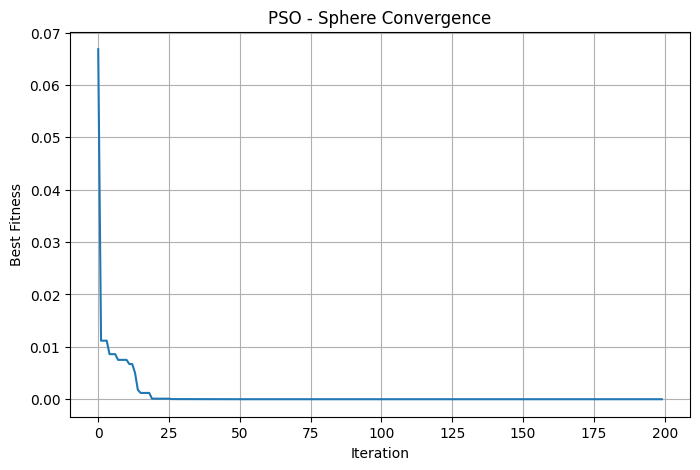

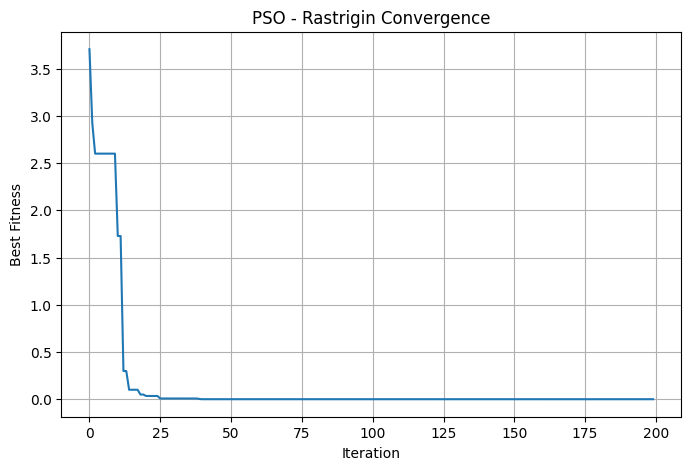

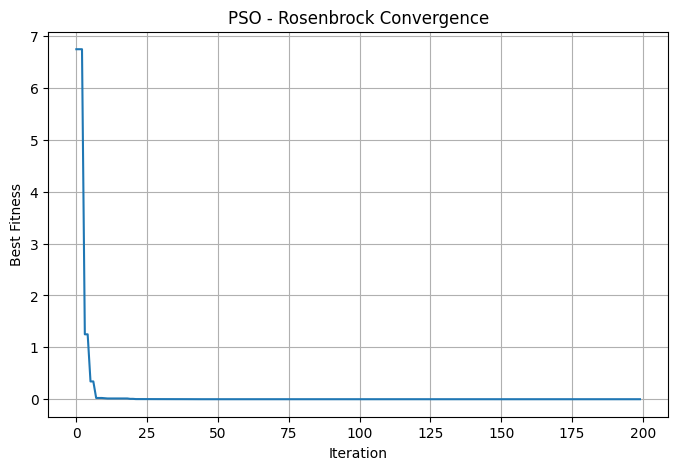

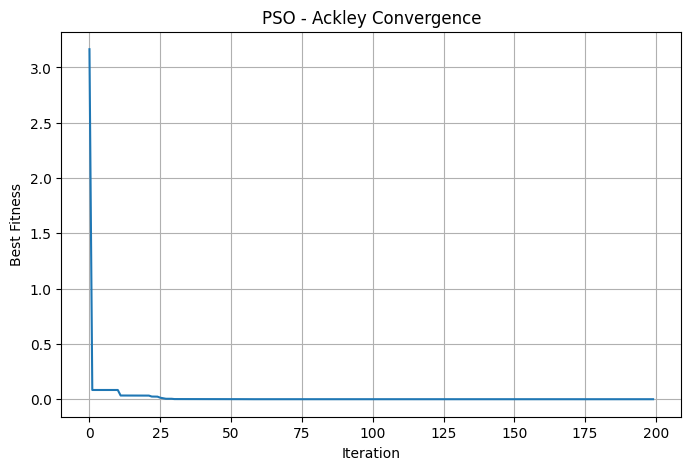

In [23]:
plot_convergence(
    sphere_result["history"],
    "PSO - Sphere Convergence"
)

plot_convergence(
    rastrigin_result["history"],
    "PSO - Rastrigin Convergence"
)

plot_convergence(
    rosenbrock_result["history"],
    "PSO - Rosenbrock Convergence"
)

plot_convergence(
    ackley_result["history"],
    "PSO - Ackley Convergence"
)

In [24]:
def plot_function_surface(
    function,
    bounds,
    title
):
    x = np.linspace(
        bounds[0][0],
        bounds[0][1],
        100
    )
    y = np.linspace(
        bounds[1][0],
        bounds[1][1],
        100
    )
    X,Y = np.meshgrid(
        x,
        y
    )
    Z = np.zeros_like(X)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            Z[i,j] = function(
                np.array(
                    [
                        X[i,j],
                        Y[i,j]
                    ]
                )
            )
    fig = plt.figure(
        figsize=(8,6)
    )
    ax = fig.add_subplot(
        111,
        projection="3d"
    )
    ax.plot_surface(
        X,
        Y,
        Z
    )
    ax.set_title(
        title
    )
    plt.show()

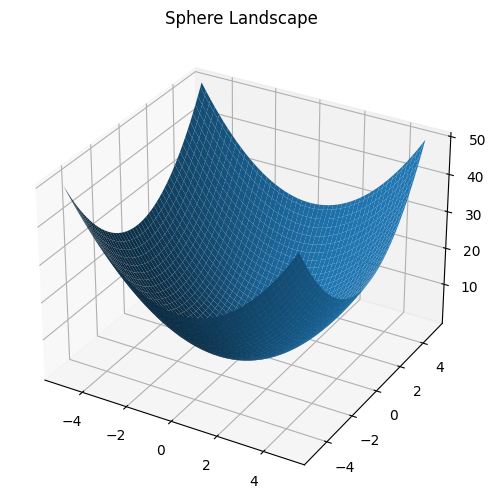

In [25]:
plot_function_surface(
    sphere_function,
    sphere_bounds,
    "Sphere Landscape"
)

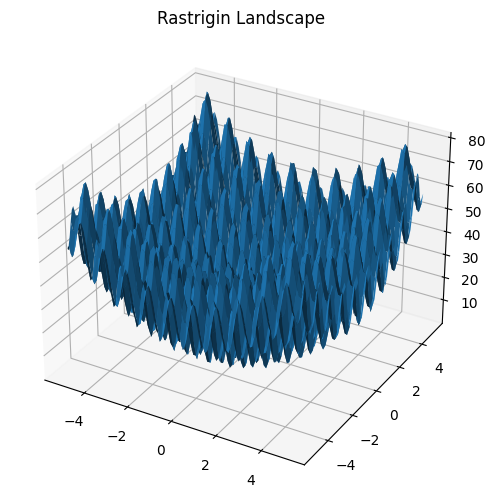

In [26]:
plot_function_surface(
    rastrigin_function,
    rastrigin_bounds,
    "Rastrigin Landscape"
)

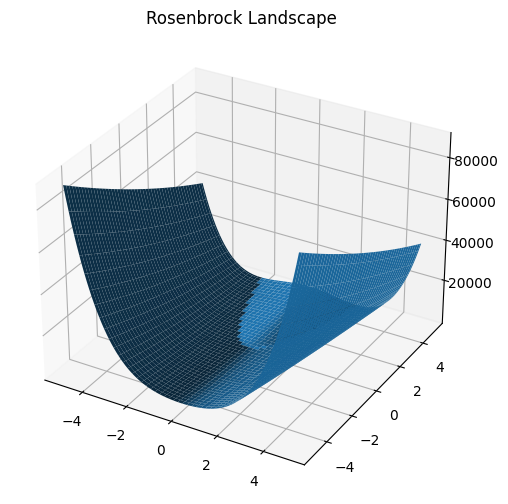

In [27]:
plot_function_surface(
    rosenbrock_function,
    rosenbrock_bounds,
    "Rosenbrock Landscape"
)

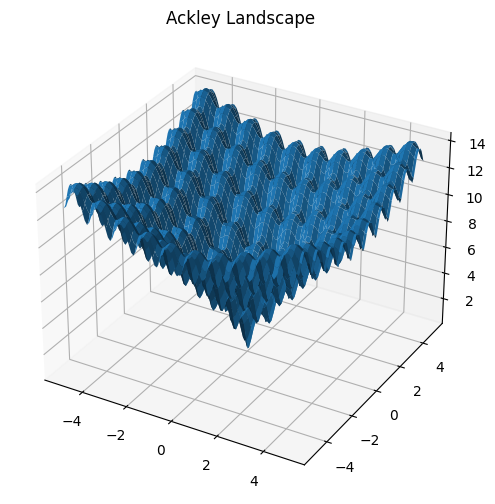

In [28]:
plot_function_surface(
    ackley_function,
    ackley_bounds,
    "Ackley Landscape"
)

<h3> Step 7.2: Particles Movement </h3>

In [29]:
def plot_particle_movement(
    particle_history,
    gbest,
    title
):
    plt.figure(
        figsize=(8,6)
    )
    particle_history = np.array(
        particle_history
    )

    num_particles = particle_history.shape[1]

    for i in range(num_particles):
        path = particle_history[:,i,:]
        plt.plot(
            path[:,0],
            path[:,1],
            marker="o",
            markersize=2,
            alpha=0.5
        )

        # final position
        plt.scatter(
            path[-1,0],
            path[-1,1],
            s=40
        )

    # Global Best
    plt.scatter(
        gbest[0],
        gbest[1],
        s=120,
        marker="*"
    )

    plt.xlabel(
        "X1"
    )
    plt.ylabel(
        "X2"
    )
    plt.title(
        title
    )

    plt.grid()
    plt.show()

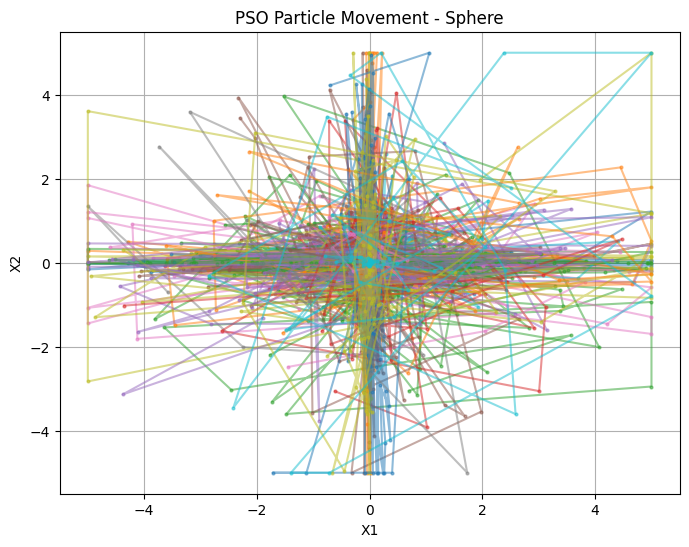

In [30]:
plot_particle_movement(
    sphere_result["particle_history"],
    sphere_result["solution"],
    "PSO Particle Movement - Sphere"
)

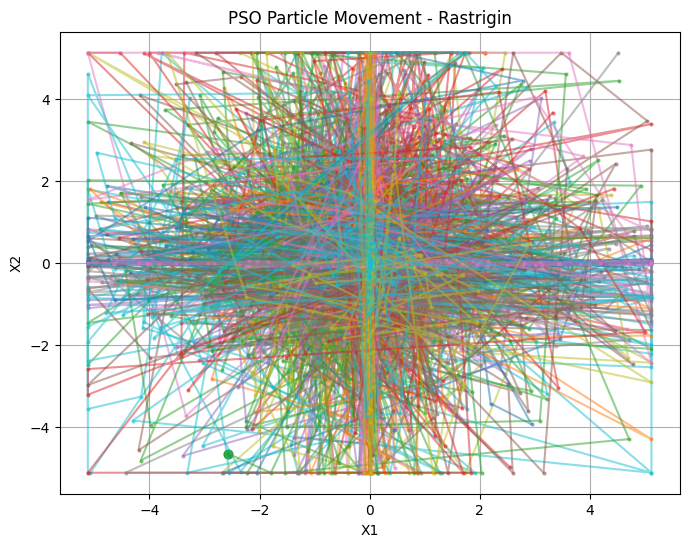

In [31]:
plot_particle_movement(
    rastrigin_result["particle_history"],
    rastrigin_result["solution"],
    "PSO Particle Movement - Rastrigin"
)

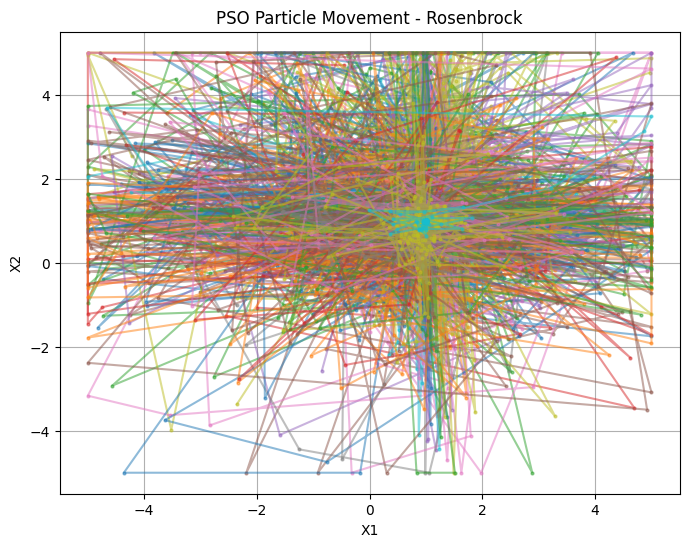

In [32]:
plot_particle_movement(
    rosenbrock_result["particle_history"],
    rosenbrock_result["solution"],
    "PSO Particle Movement - Rosenbrock"
)

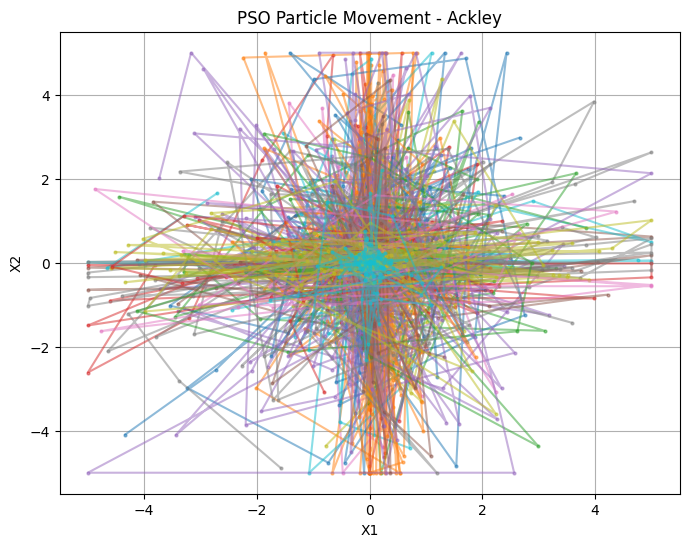

In [33]:
plot_particle_movement(
    ackley_result["particle_history"],
    ackley_result["solution"],
    "PSO Particle Movement - Ackley"
)